# Inference Analysis

Local analysis notebook for inspecting inference outputs.
Works on both the Linux server and macOS (via NAS mount + symlink).

In [2]:
import platform
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd

from vascular_superenhancement.utils.path_config import load_path_config

config_name = "local_mac" if platform.system() == "Darwin" else "all_patients"
pc = load_path_config(config_name)

WORKING_DIR = pc.working_dir
INFERENCE_DIR = WORKING_DIR.parent / "inference"
PATIENT_DATA_DIR = WORKING_DIR / "patient_data"

print(f"Platform:      {platform.system()}")
print(f"Config:        {config_name}")
print(f"Working dir:   {WORKING_DIR}")
print(f"Inference dir: {INFERENCE_DIR}")
print(f"Patient data:  {PATIENT_DATA_DIR}")

Found project root at: /Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow
Platform:      Darwin
Config:        local_mac
Working dir:   /Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow/working_dir/all_patients
Inference dir: /Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow/working_dir/inference
Patient data:  /Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data


In [3]:
inference_runs = sorted([d.name for d in INFERENCE_DIR.iterdir() if d.is_dir()])
print(f"Available inference runs ({len(inference_runs)}):")
for run in inference_runs:
    n_patients = len(list((INFERENCE_DIR / run).iterdir()))
    print(f"  {run}  ({n_patients} items)")

Available inference runs (10):
  desiring-ring_epoch-180  (12 items)
  devoted-frost-50_epoch-630  (26 items)
  devoted-frost-50_epoch-630_all_timepoints  (30 items)
  expert-tree-93_all-mag-methods  (28 items)
  frosty-monkey-45_epoch-999  (27 items)
  senate  (8 items)
  test_all_timepoints  (1 items)
  vibrant-energy-83_epoch-19+10_all-timepoints  (28 items)
  vivid-donkey-37  (24 items)
  zesty-surf-38_epoch-840  (24 items)


In [4]:
# --- Pick a run and patient to inspect ---
RUN_NAME = "desiring-ring_epoch-180"  # <-- change this
PATIENT_ID = "Balboloop"                                 # <-- change this
TIMEPOINT = 0

pred_dir = INFERENCE_DIR / RUN_NAME / PATIENT_ID / "predicted_mag" / "naive"
pred_files = sorted(pred_dir.glob("*.nii.gz"))
print(pred_dir)
print(f"Predictions for {PATIENT_ID} in {RUN_NAME}: {len(pred_files)} timepoints")
for f in pred_files[:5]:
    print(f"  {f.name}")
if len(pred_files) > 5:
    print(f"  ... and {len(pred_files) - 5} more")

/Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow/working_dir/inference/desiring-ring_epoch-180/Balboloop/predicted_mag/naive
Predictions for Balboloop in desiring-ring_epoch-180: 20 timepoints
  pred_mag_Balboloop_frame_00.nii.gz
  pred_mag_Balboloop_frame_01.nii.gz
  pred_mag_Balboloop_frame_02.nii.gz
  pred_mag_Balboloop_frame_03.nii.gz
  pred_mag_Balboloop_frame_04.nii.gz
  ... and 15 more


In [8]:
# --- Load prediction and ground truth for a single timepoint ---
pred_img = nib.load(str(pred_files[TIMEPOINT]))
pred_data = pred_img.get_fdata()
print(f"Prediction shape: {pred_data.shape}, dtype: {pred_data.dtype}")
print(f"  range: [{pred_data.min():.4f}, {pred_data.max():.4f}]")

# Load corresponding ground truth 3D cine timepoint if available
gt_dir = PATIENT_DATA_DIR / PATIENT_ID / "nifti" / f"4d_flow_mag_{PATIENT_ID}_per_timepoint_corr_fov"
gt_files = sorted(gt_dir.glob("*.nii.gz")) if gt_dir.exists() else []
if gt_files:
    gt_img = nib.load(str(gt_files[TIMEPOINT]))
    gt_data = gt_img.get_fdata()
    print(f"Ground truth shape: {gt_data.shape}, dtype: {gt_data.dtype}")
    print(f"  range: [{gt_data.min():.4f}, {gt_data.max():.4f}]")
else:
    gt_data = None
    print("No ground truth timepoints found")

Prediction shape: (256, 178, 140), dtype: float64
  range: [0.0000, 0.6613]
Ground truth shape: (256, 178, 140), dtype: float64
  range: [0.0000, 4924.0000]


In [7]:
print(gt_dir)
print("/Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Balboloop/nifti/4d_flow_mag_Balboloop_per_timepoint_corr_fov")

/Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Balboloop/nifti/4d_flow_mag_Balboloop_per_timepoint_corr_flow
/Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Balboloop/nifti/4d_flow_mag_Balboloop_per_timepoint_corr_fov


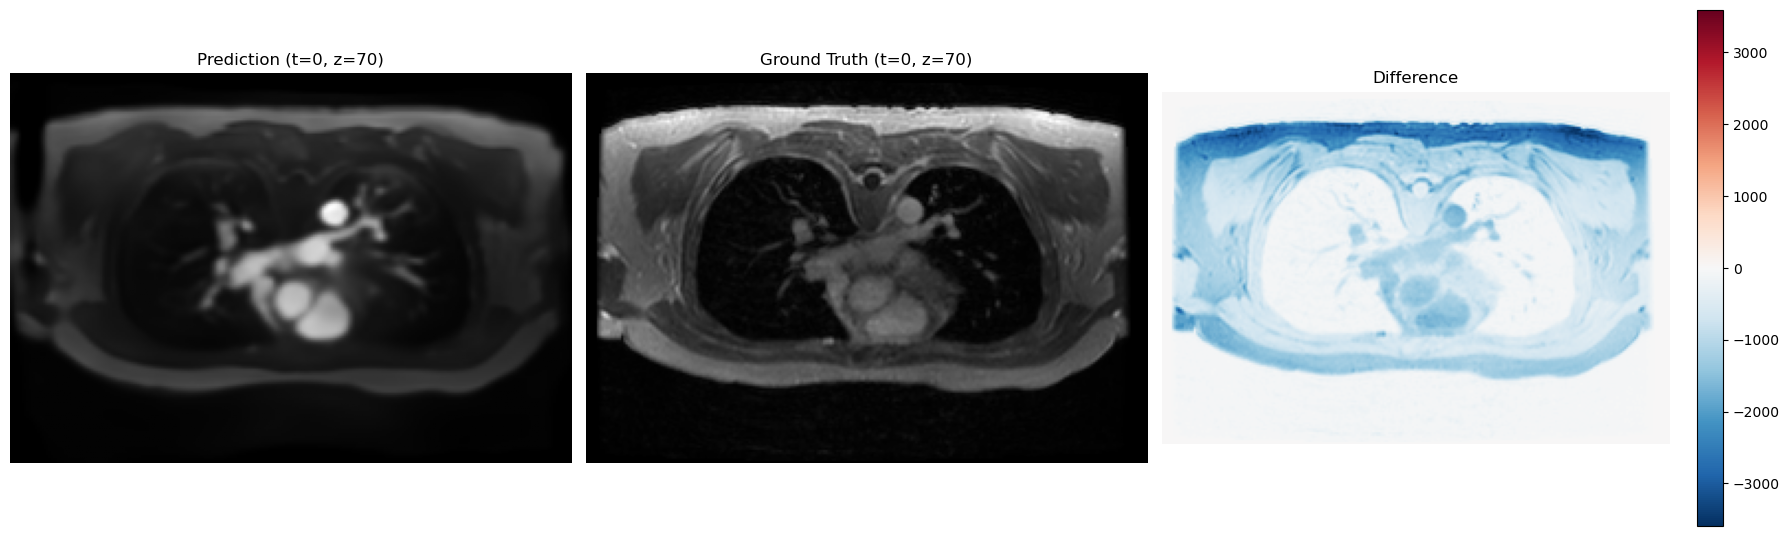

In [9]:
# --- Visualize mid-slices ---
mid_z = pred_data.shape[2] // 2

n_cols = 3 if gt_data is not None else 1
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))
if n_cols == 1:
    axes = [axes]

axes[0].imshow(pred_data[:, :, mid_z].T, cmap="gray", origin="lower")
axes[0].set_title(f"Prediction (t={TIMEPOINT}, z={mid_z})")

if gt_data is not None:
    axes[1].imshow(gt_data[:, :, mid_z].T, cmap="gray", origin="lower")
    axes[1].set_title(f"Ground Truth (t={TIMEPOINT}, z={mid_z})")

    diff = pred_data[:, :, mid_z] - gt_data[:, :, mid_z]
    im = axes[2].imshow(diff.T, cmap="RdBu_r", origin="lower",
                        vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
    axes[2].set_title("Difference")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()